# ggplotpy synthetic gallery — edge cases + extensions

Demonstrates synthetic datasets (empty groups, extreme scales), optional extensions
(ggrepel, patchwork `|`/`/` on `GG` objects, gganimate), and Arrow ingress when available.

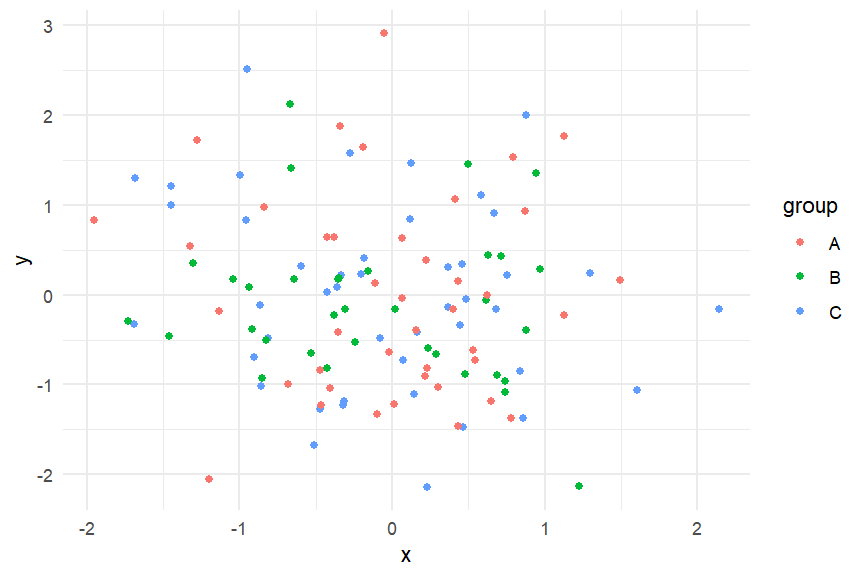

In [2]:
from ggplotpy import *
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 120
df = pd.DataFrame({
    'x': rng.normal(0, 1, n),
    'y': rng.normal(0, 1, n),
    'group': rng.choice(['A', 'B', 'C'], n),
    'year': rng.integers(2018, 2023, n),
    'label': [f'pt{i}' for i in range(n)],
})
p = ggplot(df) + aes(x='x', y='y', color='group') + geom_point() + theme_minimal()
p

## Edge case — single-level factor + extreme outlier

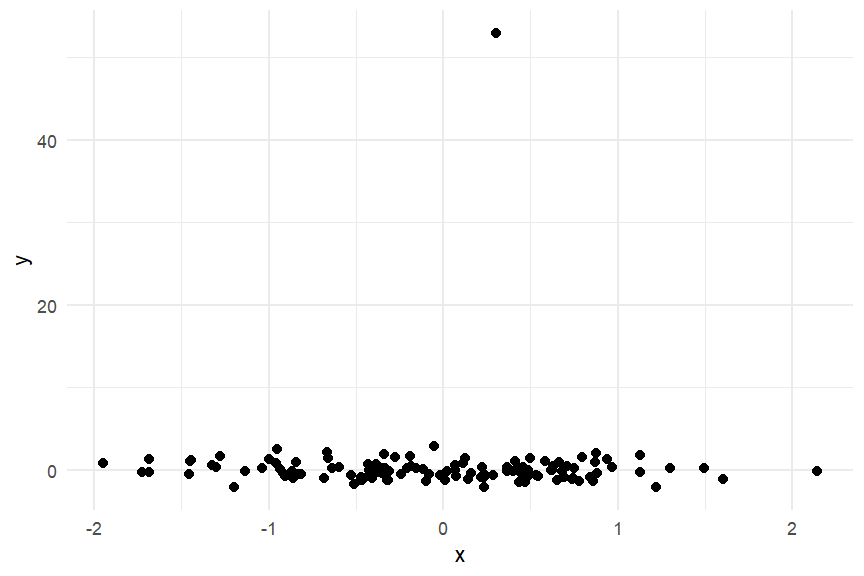

In [4]:
edge = df.copy()
edge.loc[0, 'y'] = edge['y'].max() + 50
edge['group'] = 'solo'
ggplot(edge) + aes(x='x', y='y') + geom_point(size=2) + theme_minimal()

## ggrepel (optional)

In [5]:
try:
    import ggplotpy.ext as ext
    p_repel = p + ext.ggrepel.geom_text_repel(aes(label='label'), max_overlaps=8)
    p_repel
except Exception as exc:
    print('ggrepel skipped:', exc)

ggrepel skipped: Extension package 'ggrepel' is not installed. Run in R: install.packages('ggrepel')


## patchwork — direct `|` and `/` on GG objects (optional)

In [6]:
p1 = ggplot(df) + aes(x='x', y='y') + geom_point()
p2 = ggplot(df) + aes(x='year', y='y') + geom_point()
try:
    (p1 | p2)
except Exception as exc:
    print('patchwork skipped:', exc)

## gganimate (optional — needs gifski)

In [3]:
from ggplotpy.core.animate import transition_states, animate

try:
    anim_plot = p + transition_states(states='year')
    gif_bytes = animate(anim_plot, width=320, height=240, fps=5)
    print(f'GIF bytes: {len(gif_bytes)}')
except Exception as exc:
    print('gganimate skipped:', exc)

R callback write-console: Error in loadNamespace(x) : there is no package called 'gganimate'
  


gganimate skipped: Error in loadNamespace(x) : there is no package called 'gganimate'



## Arrow ingress (optional pyarrow extra)

In [ ]:
try:
    import pyarrow as pa
    from ggplotpy.data.arrow import arrow_to_r
    table = pa.Table.from_pandas(df)
    r_df = arrow_to_r(table)
    ggplot(r_df) + aes(x='x', y='y', color='group') + geom_point()
except ImportError:
    print('pyarrow extra not installed — pip install ggplotpy[arrow]')